# **FASE 3 - Detección temparana**

In [1]:
# ==========================================
# 1. LIBRERÍAS
# ==========================================

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import matplotlib.pyplot as plt

In [2]:
# ==========================================
# 2. MONTAJE GOOGLE DRIVE
# ==========================================

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ==========================================
# 3. CARGA DATASETS
# ==========================================

VENTANAS_ESTUDIO = [
    1,
    2,
    5,
    10,
    30
]

RUTA_BASE = (
    "/content/drive/MyDrive/TFM/"
    "Datasets_Ventanas_V2"
)

In [4]:
# ==========================================
# 4. VENTANAS DE ESTUDIO
# ==========================================

datasets = {}

for ventana in VENTANAS_ESTUDIO:

    ruta = (
        f"{RUTA_BASE}/"
        f"dataset_{ventana}s.csv"
    )

    datasets[ventana] = pd.read_csv(ruta)

    print(
        f"Ventana {ventana}s: "
        f"{datasets[ventana].shape}"
    )

Ventana 1s: (516249, 20)
Ventana 2s: (266912, 20)
Ventana 5s: (114497, 20)
Ventana 10s: (59762, 20)
Ventana 30s: (21247, 20)


In [5]:
# ==========================================
# 5. VARIABLES ML
# ==========================================

COLUMNAS_EXCLUIDAS = [

    "ventana_id",

    "tiempo_inicio",
    "tiempo_fin",

    "escenario",
    "tipo_escenario",

    "ventana_global",

    "label_binaria",

    "primer_ts_malicioso_ventana",

    "inicio_real_ataque_escenario"

]

In [7]:
# ==========================================
# 6. MODELOS
# ==========================================

modelos = {

    "Logistic Regression":

        LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ),

    "Decision Tree":

        DecisionTreeClassifier(
            class_weight="balanced",
            random_state=42
        ),

    "Random Forest":

        RandomForestClassifier(
            n_estimators=100,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),

    "XGBoost":

        XGBClassifier(
            n_estimators=100,
            max_depth=6,
            random_state=42,
            eval_metric="logloss"
        )

}

In [9]:
# ==========================================
# 7. ENTRENAMIENTO Y PREDICCIONES
# ==========================================

predicciones = {}

for ventana, df in datasets.items():

    print(f"\nProcesando {ventana}s")

    train_df = df[
        df["escenario"] != "C&C"
    ].copy()

    test_df = df[
        df["escenario"] == "C&C"
    ].copy()

    test_df = (
        test_df
        .sort_values("tiempo_inicio")
        .reset_index(drop=True)
    )

    X_train = train_df.drop(
        columns=COLUMNAS_EXCLUIDAS
    )

    X_test = test_df.drop(
        columns=COLUMNAS_EXCLUIDAS
    )

    y_train = train_df["label_binaria"]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(
        X_train
    )

    X_test = scaler.transform(
        X_test
    )

    for nombre, modelo in modelos.items():

        modelo.fit(
            X_train,
            y_train
        )

        pred = modelo.predict(
            X_test
        )

        resultado = test_df.copy()

        resultado["prediccion"] = pred

        predicciones[
            (ventana, nombre)
        ] = resultado


Procesando 1s

Procesando 2s

Procesando 5s

Procesando 10s

Procesando 30s


In [10]:
# ==========================================
# 8. PREPARACIÓN DATOS
# ==========================================

X_train = train_df.drop(
    columns=COLUMNAS_EXCLUIDAS
)

X_test = test_df.drop(
    columns=COLUMNAS_EXCLUIDAS
)

y_train = train_df[
    "label_binaria"
]

y_test = test_df[
    "label_binaria"
]

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

In [11]:
# ==========================================
# 9. LATENCIA
# ==========================================

def calcular_latencia(
        df_pred):

    inicio_real = (

        df_pred[
            "inicio_real_ataque_escenario"
        ]

        .iloc[0]

    )

    detecciones = df_pred[

        (df_pred["prediccion"] == 1)

        &

        (
            df_pred["tiempo_inicio"]
            >= inicio_real
        )

    ]

    if len(detecciones) == 0:

        return None

    primera_deteccion = (

        detecciones[
            "tiempo_inicio"
        ]

        .min()

    )

    return (

        primera_deteccion

        -

        inicio_real

    )

In [12]:
# ==========================================
# 10. CALCULO DE LATENCIA
# ==========================================

resultados = []

for clave, df_pred in predicciones.items():

    ventana, modelo = clave

    latencia = calcular_latencia(
        df_pred
    )

    resultados.append({

        "Ventana":
        ventana,

        "Modelo":
        modelo,

        "Latencia (s)":
        latencia

    })

df_latencias = pd.DataFrame(
    resultados
)

df_latencias

,Ventana,Modelo,Latencia (s)
0,1,Logistic Regression,15.713805
1,1,Decision Tree,0.000000
2,1,Random Forest,0.000000
3,1,XGBoost,0.000000
4,2,Logistic Regression,202.685978
5,2,Decision Tree,0.000000
6,2,Random Forest,0.000000
7,2,XGBoost,0.000000
8,5,Logistic Regression,41717.672784
9,5,Decision Tree,5.725242


In [13]:
# ==========================================
# 11. PRIMERA DETECCIÓN
# ==========================================

df_latencias.sort_values(

    ["Modelo", "Ventana"]

)

,Ventana,Modelo,Latencia (s)
1,1,Decision Tree,0.000000
5,2,Decision Tree,0.000000
9,5,Decision Tree,5.725242
13,10,Decision Tree,5.725242
17,30,Decision Tree,40.032712
0,1,Logistic Regression,15.713805
4,2,Logistic Regression,202.685978
8,5,Logistic Regression,41717.672784
12,10,Logistic Regression,41717.672784
16,30,Logistic Regression,178.266196


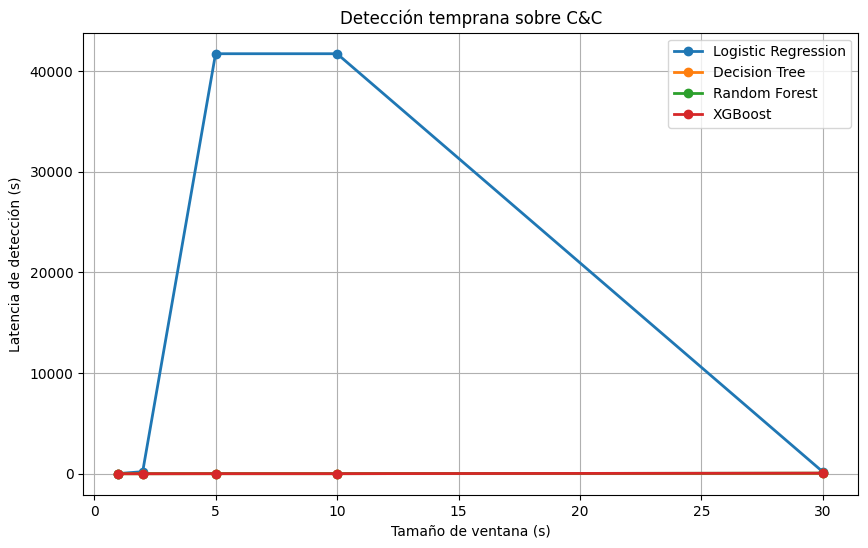

In [14]:
# ==========================================
# 12. GRÁFICAS
# ==========================================

plt.figure(
    figsize=(10,6)
)

for modelo in df_latencias[
    "Modelo"
].unique():

    datos = df_latencias[
        df_latencias["Modelo"]
        == modelo
    ]

    plt.plot(

        datos["Ventana"],

        datos["Latencia (s)"],

        marker="o",

        linewidth=2,

        label=modelo

    )

plt.xlabel(
    "Tamaño de ventana (s)"
)

plt.ylabel(
    "Latencia de detección (s)"
)

plt.title(
    "Detección temprana sobre C&C"
)

plt.legend()

plt.grid()

plt.show()

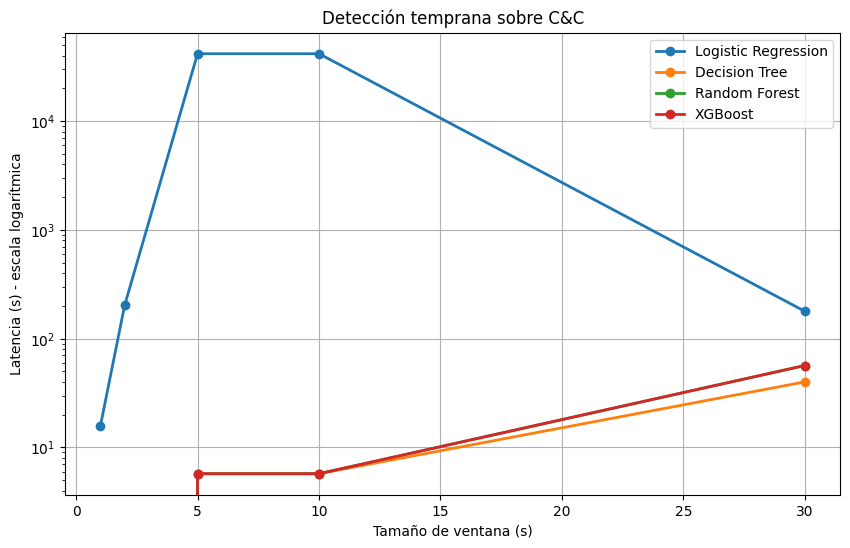

In [15]:
# ==========================================
# 12.1 GRÁFICAS log
# ==========================================

plt.figure(figsize=(10,6))

for modelo in df_latencias["Modelo"].unique():

    datos = df_latencias[
        df_latencias["Modelo"] == modelo
    ]

    plt.plot(
        datos["Ventana"],
        datos["Latencia (s)"],
        marker="o",
        linewidth=2,
        label=modelo
    )

plt.yscale("log")

plt.xlabel("Tamaño de ventana (s)")
plt.ylabel("Latencia (s) - escala logarítmica")

plt.title(
    "Detección temprana sobre C&C"
)

plt.legend()

plt.grid(True)

plt.show()

In [16]:
# ==========================================
# 13. TABLA COMPARATIVA LATENCIAS
# ==========================================

df_latencias.pivot(

    index="Ventana",

    columns="Modelo",

    values="Latencia (s)"

)

Modelo,Decision Tree,Logistic Regression,Random Forest,XGBoost
Ventana,,,,
1,0.000000,15.713805,0.000000,0.000000
2,0.000000,202.685978,0.000000,0.000000
5,5.725242,41717.672784,5.725242,5.725242
10,5.725242,41717.672784,5.725242,5.725242
30,40.032712,178.266196,56.631264,56.631264


In [17]:
# ==========================================
# 14. ALMACENAMIENTO DE RESULTADOS
# ==========================================

ruta_csv = (
    "/content/drive/MyDrive/TFM/"
    "latencia_C&C_v3.csv"
)

df_latencias.to_csv(
    ruta_csv,
    index=False
)

print(
    "✅ Resultados guardados"
)


✅ Resultados guardados
